#Jupyter notebook to test LWR library

This code uses the code made by Randall J. LeVeque to model traffic flow and "shock waves" for modelling traffic lights and traffic jams. This only works in jupyter notebook.

In [49]:
import sys
import os
%matplotlib inline

# Add the riemann_book folder to Python's path
sys.path.append(os.path.join(os.getcwd(), 'riemann_book'))

import matplotlib as mpl
mpl.rcParams['font.size'] = 8
figsize =(8,4)
mpl.rcParams['figure.figsize'] = figsize

import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
from ipywidgets import widgets, FloatSlider

from utils import riemann_tools
from exact_solvers import traffic_LWR, Redlight

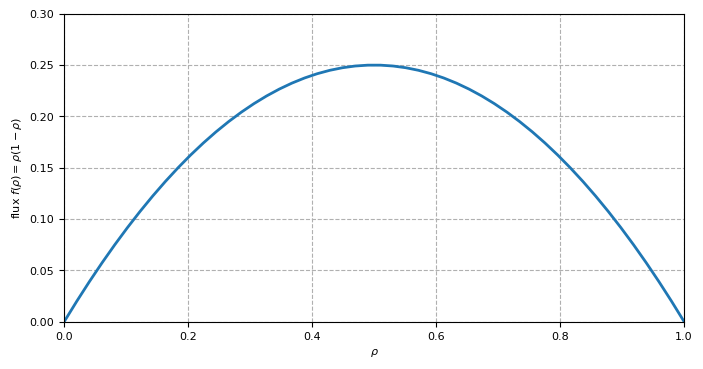

In [20]:
rho = np.linspace(0,1)
f = rho*(1.-rho)
plt.plot(rho,f,linewidth=2)
plt.xlabel(r'$\rho$'); plt.ylabel(r'flux $f(\rho) = \rho(1-\rho)$');
plt.ylim(0,0.3); plt.xlim(0,1); plt.grid(linestyle='--');

This plot demonstrates how the flux of a section of road is affected. BEcause flow rate depends on density, the extremes are both 0 as they are either static traffic or an empty road. In between the linear vel. dependence from the rgo(1-rho eqn is shown). so the maximum flux is at the middle of the graph where density is high but so is car speed.

In [24]:
def jam(rho_l=0.4,t=0.1):
    shock_speed = -rho_l
    #shock speed can be derived to just be dependent on incoming density
    shock_location = t*shock_speed
    #shock location varies with speed
    fig, axes = plt.subplots(1,2,figsize=figsize)
    #plots two horizontal lines at 1 and the chosen density of incoming traffic
    axes[0].plot([-1,shock_location],[rho_l,rho_l],'k',lw=2)
    #this line below specifically plots a verticle line which represents the shock
    axes[0].plot([shock_location,shock_location],[rho_l,1.],'k',lw=2)
    axes[0].plot([shock_location,1.],[1.,1.],'k',lw=2)
    axes[0].set_xlabel('$x$'); axes[0].set_ylabel(r'$\rho$'); 
    axes[0].set_xlim(-0.2,0.2); axes[0].set_ylim(0,1.1)
    traffic_LWR.plot_car_trajectories(rho_l,1.,axes[1]); 
    axes[1].set_ylim(0,1); axes[0].set_title(r'$t= $'+str(t))
    plt.xlabel('$x$'); plt.ylabel(r'$t$');
    plt.show()
    
interact(jam,
         rho_l=FloatSlider(min=0.,max=0.9,value=0.2,description=r'rho_l'),
         t=FloatSlider(min=0.,max=1.,value=0.2));


interactive(children=(FloatSlider(value=0.2, description='rho_l', max=0.9), FloatSlider(value=0.2, description…

These plots show the two key ideas behind the Rankine–Hugoniot condition for a traffic jam. The left hand graph is simply for a set time t, what is the density of cars at a position x on the road, this depends on rho_l (as it defines the shock wave speed) and the time after the shock wave begins t (i.e. as t increases it moves further back). 
The right had graph is how the cars move wrt time. s(speed of shock wave) is dependent on in flow density (rho_l) so if rho_l increases then the traffic backs up more quickly. The traffic above 0 is assumed to be static i.e. no change in x over time. The vehicles left of 0 are less dense, and move until they hit the distance behind the car infront where they need to stop. plotting these distances as the traffic accumulates. By increasing rho_l you can increases the number of cars approaching in the space -0.6 to 0. This not only forces the incoming cars closer together but increases the rate the shock wave moves at. The shockwave is the red line on the RHS graph.

In [ ]:
def green_light(rho_r=0.,t=0.1):
    rho_l = 0.1
    left_edge = -t
    right_edge = -t*(2*rho_r - 1)
    fig, axes = plt.subplots(1,2,figsize=figsize)
    axes[0].plot([-1,left_edge],[rho_l,rho_l],'k',lw=2)
    axes[0].plot([left_edge,right_edge],[rho_l,rho_r],'k',lw=2)
    axes[0].plot([right_edge,1.],[rho_r,rho_r],'k',lw=2)
    axes[0].set_xlabel('$x$'); axes[0].set_ylabel(r'$\rho$');
    axes[0].set_xlim(-1,1);  axes[0].set_ylim(-0.1,1.1)
    plt.xlabel('$x$'); plt.ylabel(r'$t$');
   
    traffic_LWR.plot_car_trajectories(0.7,rho_r,axes[1],t=t,xmax=1.); 
    axes[1].set_ylim(0,1)
    plt.show()    

interact(green_light,
         rho_r=FloatSlider(min=0.,max=0.9,value=0.,description=r'$\rho_r$'),
         t=FloatSlider(min=0.,max=1.));

interactive(children=(FloatSlider(value=0.0, description='$\\rho_r$', max=0.9), FloatSlider(value=0.0, descrip…

These graphs are similar to the case before, except now it is reversed. This can be viewd as the front of a traffic jam or slow region, where the traffic has open road and can speed up. This is a bit stranger though as its not just a case of stopping its how one car accelerates then a next and so on its a ripple effect and takes time. 

The math dictates that for a decrease in density it must be a shockwave. ANd for an increasing density it must be a rarefraction.

The code below is code that plots the interaction between the green wave and the shock wave as the traffic jam dissipates. This uses the greenshields linear model as use of a more advanced velocity formula would make the ODE horrible to solve. It uses the assumption that densities are expressed as a fraction of the total density i.e. rho_max=1 and v_max=1 so the maths doesnt have lots of constants floating around. so if v_maxreal=60mph the v_max=1 would be 1=60/60 and so forth for v_car=50 it would be 30/60=0.5 etc and same for density. A density of 1 would be the entire road is jammed. 

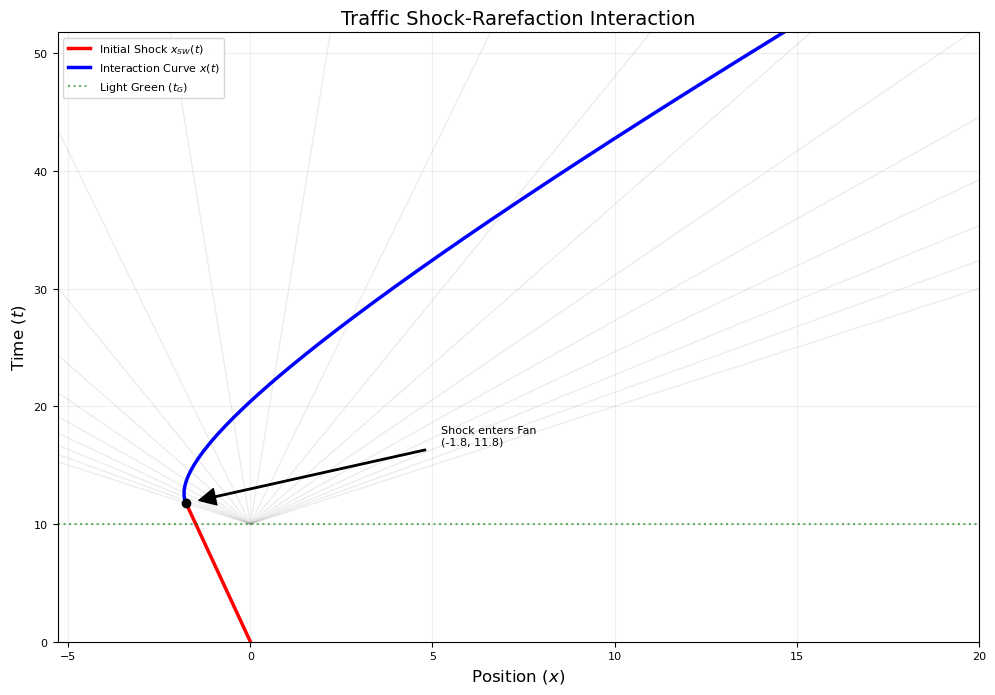

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters 
rho_in = 0.15
t_R = 0
t_delay = 10
t_G = t_R + t_delay
D = 0
s = -rho_in  # Shock speed

# Transition Point
t_star = (t_G + s * t_R) / (1 + s)
x_star = D + s * (t_star - t_R)

# Ranges
t_max = t_star + 40
t_fan = np.linspace(t_G, t_max, 100)

plt.figure(figsize=(10, 7))

# Rarefaction Fan 
# These represent the 'information' waves spreading out from the green light
fan_slopes = np.linspace(-1, 1, 20) 
for slope in fan_slopes:
    # x = v*t -> in this plot x = D + slope * (t - t_G)
    x_f = D + slope * (t_fan - t_G)
    plt.plot(x_f, t_fan, color='gray', alpha=0.15, lw=1)

# Initial Shock Wave
t_sw = np.linspace(t_R, t_star, 100)
x_sw = D + s * (t_sw - t_R)
plt.plot(x_sw, t_sw, 'r', lw=2.5, label='Initial Shock $x_{SW}(t)$')

# Transition Region
t_trans = np.linspace(t_star, t_max, 400)
lin_term = (1 - 2 * rho_in) * (t_trans - t_G)
sqrt_inner = (s * (t_R - t_G) * (t_trans - t_G)) / (1 + s)
decay_term = - 2 * (1 - rho_in) * np.sqrt(sqrt_inner)
x_t = lin_term + D + decay_term
plt.plot(x_t, t_trans, 'b', lw=2.5, label='Interaction Curve $x(t)$')

# Annotations & Formatting
plt.scatter([x_star], [t_star], color='black', zorder=5)
plt.annotate(f'Shock enters Fan\n({x_star:.1f}, {t_star:.1f})', 
             xy=(x_star, t_star), xytext=(x_star + 7, t_star + 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.axhline(t_G, color='green', ls=':', alpha=0.6, label='Light Green ($t_G$)')
plt.title('Traffic Shock-Rarefaction Interaction', fontsize=14)
plt.xlabel('Position ($x$)', fontsize=12)
plt.ylabel('Time ($t$)', fontsize=12)
plt.xlim(x_star * 3, 20)
plt.ylim(0, t_max)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()